In [1]:
import os, random, re
import pandas as pd
import numpy as np
# import plotly.subplots as sp
# import plotly.graph_objects as go

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import spotipy
from spotipy.oauth2 import SpotifyOAuth

# Display Random Session

In [2]:
def load_session_data(session_path, signals_to_plot):
    """
    Load session data for the selected physiological signals.
    Returns a dictionary with signal name as key and its DataFrame as value.
    """
    data = {}
    for signal in signals_to_plot:
        signal_path = os.path.join(session_path, f"{signal}.csv")
        if os.path.exists(signal_path):
            data[signal] = pd.read_csv(signal_path)
    return data

def get_random_session(raw_data_path):
    """
    Select a random session from the directory structure.
    """
    sessions = []
    for root, dirs, _ in os.walk(raw_data_path):
        for dir_name in dirs:
            if '_' in dir_name and dir_name.count('_') == 2:
                sessions.append(os.path.join(root, dir_name))
    return random.choice(sessions) if sessions else None


In [3]:
# Set the raw data path and signals to plot
RAW_DATA_PATH = "../data/raw"
to_plot = ['eda', 'bvp', 'temperature', "accelerometer"]

# Get a random session
random_session = get_random_session(RAW_DATA_PATH)
if not random_session:
    raise ValueError("No valid sessions found in the specified directory structure.")

# random_session = "../data/raw/P01/1736286699_1736288510_12"
# random_session = "../data/raw/P01/1736288510_1736291315_13"

# Load data for the selected session
session_data = load_session_data(random_session, to_plot)

# Load tracks.csv to get song start and end times
tracks_path = os.path.join(random_session, "tracks.csv")
tracks = pd.read_csv(tracks_path) if os.path.exists(tracks_path) else None


In [4]:
# # Create a subplot layout for the signals
# fig = sp.make_subplots(rows=len(session_data), cols=1, shared_xaxes=True, 
#                        subplot_titles=to_plot)

# # Iterate through signals and add traces
# for i, (signal, df) in enumerate(session_data.items(), start=1):
#     if 'unix_timestamp' in df.columns:
#         x = pd.to_datetime(df['unix_timestamp'], unit='us')  # Convert to datetime if needed
#     else:
#         x = np.arange(len(df))  # Fallback to sequential index
#     if signal == "accelerometer":
#         for axis in ['x', 'y', 'z']:
#             y = df[axis]
#             fig.add_trace(go.Scatter(x=x, y=y, name=f'Accelerometer ({axis})'), row=i, col=1)
#     else:
#         y = df.iloc[:, 1]  # Assuming the signal value is in the second column
#         fig.add_trace(go.Scatter(x=x, y=y, name=signal.capitalize()), row=i, col=1)

# colour_mapping = {"Affective":"lightblue",
#                   "Eudaimonic":"lightsalmon",
#                   "Goal-Attainment":"lightgreen",
#                   "Other":"lightcoral"}

# majority_context = tracks["context"].value_counts().sort_values(ascending=False).idxmax()

# # Highlight session duration and add track end markers
# if tracks is not None:
#     session_start = pd.to_datetime(tracks['started_at'].min(), unit='us')
#     session_end = pd.to_datetime(tracks['ended_at'].max(), unit='us')
    
#     # Add a vrect for the entire session
#     fig.add_vrect(
#         x0=session_start, x1=session_end,
#         fillcolor=colour_mapping[majority_context], opacity=0.4, line_width=0
#     )
    
#     # Add vertical lines for each track's end, except the last one
#     for i, track in tracks.iterrows():
#         # if i < len(tracks) - 1:  # Skip the last track
#         fig.add_vline(
#             x=track["ended_at"]/1000,
#             line_dash="dash",
#             line_color="black",
#             annotation_text=f"{track['track_name']}", annotation_position="top left",
#             annotation_font_size=6
#         )

# # Update layout
# fig.update_layout(height=150*len(session_data), title=f"Session: {random_session} | {majority_context}")
# fig.show(renderer="browser")


# Basics Stats Music with Aligned Physiology

In [4]:
# Function to assign overlap group numbers
def assign_overlap_groups(sub_df):
    # Detect the start of a new group (transition from False to True)
    new_group = (sub_df['session_overlap'] & ~sub_df['session_overlap'].shift(fill_value=False)).cumsum()

    # Assign the group number to False values immediately preceding each group of True values
    new_group = new_group.where(sub_df['session_overlap'], new_group.shift(-1, fill_value=0))

    # Ensure False values not adjacent to True groups remain 0
    new_group = new_group.where(sub_df['session_overlap'] | sub_df['session_overlap'].shift(-1, fill_value=False), 0)
 
    return new_group


def get_summary_sessions(root_dataset):
    """
    
    """

    fs_eda = 4


    #
    eda_files = sorted([os.path.join(root, name)
                for root, dirs, files in os.walk(root_dataset)
                for name in files if name=="eda.csv"])
    track_files = sorted([os.path.join(root, name)
                for root, dirs, files in os.walk(root_dataset)
                for name in files if name=="tracks.csv"])


    records_sessions = []
    for eda_path, tracks_path in zip(eda_files, track_files):
        #
        df_eda = pd.read_csv(eda_path)
        df_tracks = pd.read_csv(tracks_path)

        #
        df_eda["eda_transformed"] = (df_eda["eda"] - df_eda["eda"].mean())/df_eda["eda"].std()
        df_tracks["context"] = (df_tracks["context"].astype("category")
                                .cat.add_categories({"Goal-Attainment","Eudaimonic", "Affective", "Other"} - set(df_tracks["context"])))

        #
        df_eda["condition"] = df_eda["unix_timestamp"].apply(lambda x: "pre" if x<=df_tracks["started_at"].iloc[0] else (
        "music" if df_tracks["started_at"].iloc[0]<= x <= df_tracks["ended_at"].iloc[-1] else "post"))

        #
        sessions_sumary = {
                        "participant_id" : eda_path.split("/")[-3],
                        "session_id": int(eda_path.split("/")[-2].split("_")[-1]),
                        "n_tracks": len(df_tracks),
                        "majority_context": df_tracks["context"].value_counts().idxmax(),
                        "time_start_pre" : datetime.fromtimestamp(df_eda["unix_timestamp"].iloc[0]/10e5),
                        "time_start_music":datetime.fromtimestamp(df_tracks["started_at"].iloc[0]/10e5),
                        "time_end_music":datetime.fromtimestamp(df_tracks["ended_at"].iloc[-1]/10e5),
                        "time_end_post":datetime.fromtimestamp(df_eda["unix_timestamp"].iloc[-1]/10e5)
        }

        #
        counts_tracks_context = (df_tracks["context"].value_counts()
                                .add_prefix("tracks_")
                                .to_dict())

        #
        eda_groups = (df_eda.groupby("condition").agg(
            time_minutes=pd.NamedAgg(column="eda_transformed", aggfunc=lambda x: len(x)/fs_eda/60),
            z_eda_mean=pd.NamedAgg(column="eda_transformed", aggfunc="mean"),
            z_eda_std=pd.NamedAgg(column="eda_transformed", aggfunc="std"),
            z_eda_min=pd.NamedAgg(column="eda_transformed", aggfunc="min"),
            z_eda_max=pd.NamedAgg(column="eda_transformed", aggfunc="max"),
        ).unstack())
        eda_groups.index = ["_".join(i) for i in eda_groups.index]
        eda_metrics = eda_groups.to_dict()

        #
        records_sessions.append({**sessions_sumary, **counts_tracks_context, **eda_metrics})

    #
    df_summary = pd.DataFrame(records_sessions)

    # Highlight overlapped sessions
    df_summary["session_overlap"] = (df_summary.groupby("participant_id").apply(lambda x: (timedelta(0)<= (x.sort_values(by="time_start_pre")["time_end_post"] - 
                                                                            x.sort_values(by="time_start_pre").shift(-1)["time_start_pre"])).shift(1))
                                                                            .fillna(False)
                                                                            .values)

    # Apply the function group-wise
    df_summary["overlap_group"] = df_summary.groupby('participant_id', group_keys=False).apply(assign_overlap_groups)

    return df_summary


df_summary_eda_raw = get_summary_sessions(RAW_DATA_PATH)
df_summary_eda_raw

,participant_id,session_id,n_tracks,majority_context,time_start_pre,time_start_music,time_end_music,time_end_post,tracks_Goal-Attainment,tracks_Affective,...,z_eda_std_post,z_eda_std_pre,z_eda_min_music,z_eda_min_post,z_eda_min_pre,z_eda_max_music,z_eda_max_post,z_eda_max_pre,session_overlap,overlap_group
0,P01,1,30,Goal-Attainment,2024-12-12 07:37:11.027694,2024-12-12 08:19:20.596,2024-12-12 09:35:26.140000,2024-12-12 10:37:50.777771,30,0,...,0.923250,0.322993,-3.364239,-1.953454,-3.267891,10.164752,13.598462,2.485528,False,0
1,P01,2,97,Other,2024-12-12 11:38:10.027602,2024-12-12 12:30:32.010,2024-12-12 16:16:23.328000,2024-12-12 17:40:09.810688,0,3,...,1.396302,0.029915,-0.507303,-0.495197,-0.517076,0.584304,7.606735,0.584304,False,0
2,P01,3,7,Goal-Attainment,2024-12-19 11:25:20.859770,2024-12-19 12:19:16.879,2024-12-19 12:33:07.999000,2024-12-19 13:55:54.610198,7,0,...,0.260350,0.728110,-1.027952,-2.085774,-0.859493,0.279801,2.008570,3.410071,False,0
3,P01,4,17,Goal-Attainment,2024-12-22 20:50:15.449631,2024-12-22 21:41:42.551,2024-12-22 22:25:15.782000,2024-12-22 23:50:52.198594,17,0,...,0.363621,0.581961,-1.473800,-3.012112,-1.803077,2.510948,0.945222,2.836117,False,0
4,P01,5,18,Affective,2024-12-28 12:19:23.002696,2024-12-28 12:59:32.022,2024-12-28 13:46:18.233000,2024-12-28 14:49:58.752620,0,18,...,1.060473,0.218499,-1.023134,-3.233834,0.198478,1.574684,2.802353,1.726153,False,0
5,P01,6,8,Eudaimonic,2025-01-02 16:18:37.069018,2025-01-02 17:02:12.916,2025-01-02 17:23:44.964000,2025-01-02 18:49:24.819604,0,0,...,0.817133,1.154504,-0.264886,-4.165081,-3.074910,2.517259,4.774507,3.774704,False,0
6,P01,7,22,Goal-Attainment,2025-01-07 09:48:53.521074,2025-01-07 10:40:16.667,2025-01-07 11:37:05.433000,2025-01-07 12:49:41.150315,22,0,...,1.190435,0.232759,-1.236394,-1.196071,-1.365706,0.254611,4.099840,-0.312434,False,1
7,P01,8,3,Other,2025-01-07 11:19:13.400315,2025-01-07 11:58:36.963,2025-01-07 12:08:08.553000,2025-01-07 13:19:50.150224,0,0,...,0.796190,0.185172,-1.370696,-1.821645,-1.830975,-0.053427,7.469718,1.842248,True,1
8,P01,9,6,Other,2025-01-07 12:19:28.400315,2025-01-07 13:17:53.165,2025-01-07 13:33:08.408000,2025-01-07 14:50:22.150407,0,0,...,1.005382,0.091501,-1.041298,-1.031381,-1.037382,-0.586935,3.388841,0.300219,True,1
9,P01,10,4,Other,2025-01-07 12:49:41.400224,2025-01-07 13:33:43.144,2025-01-07 13:50:47.018000,2025-01-07 15:20:22.150376,0,0,...,0.659140,0.066440,-1.330080,-1.365357,-1.340153,-0.852019,3.159741,0.022488,True,1


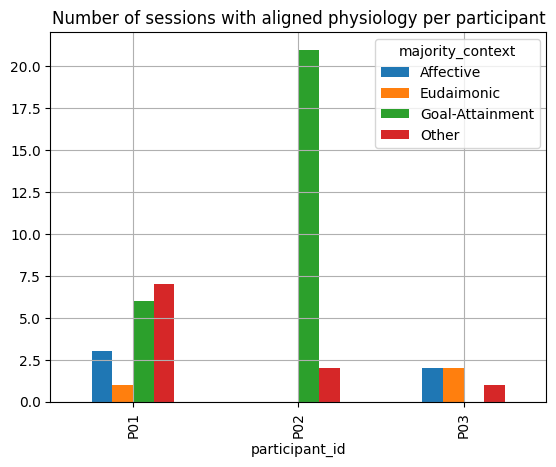

In [5]:
df_summary_eda_raw.groupby("participant_id")["majority_context"].value_counts().unstack(1).fillna(0).plot(kind="bar")
plt.grid()
plt.title("Number of sessions with aligned physiology per participant")
plt.show()

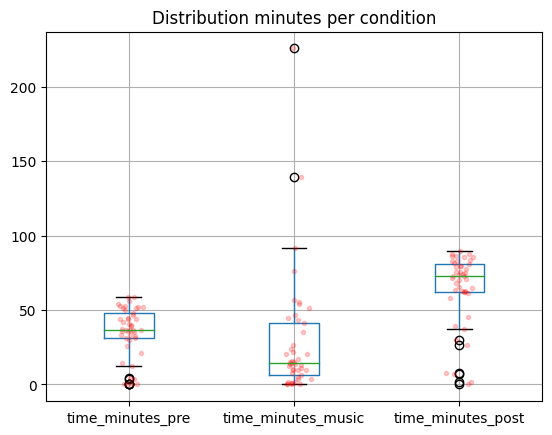

In [6]:
minutes_condition = ["time_minutes_pre", "time_minutes_music", "time_minutes_post"]

bp_minutes = df_summary_eda_raw[minutes_condition].fillna(0).boxplot()

for n_condition, condition in enumerate(minutes_condition,1):

    y = df_summary_eda_raw[condition].fillna(0)
    # Add some random "jitter" to the x-axis
    x = np.random.normal(n_condition, 0.04, size=len(y))
    plt.plot(x, y, 'r.', alpha=0.2)
plt.title("Distribution minutes per condition")    
plt.show()

In [7]:
df_summary_eda_raw[["participant_id","session_id","majority_context"] + minutes_condition]

,participant_id,session_id,majority_context,time_minutes_pre,time_minutes_music,time_minutes_post
0,P01,1,Goal-Attainment,42.162500,76.091667,62.412500
1,P01,2,Other,52.366667,225.858333,83.775000
2,P01,3,Goal-Attainment,53.937500,13.850000,82.779167
3,P01,4,Goal-Attainment,51.454167,43.554167,85.608333
4,P01,5,Affective,40.154167,46.766667,63.679167
5,P01,6,Eudaimonic,43.600000,21.533333,85.666667
6,P01,7,Goal-Attainment,51.391667,56.812500,72.595833
7,P01,8,Other,39.395833,9.525000,71.695833
8,P01,9,Other,58.416667,15.254167,77.229167
9,P01,10,Other,44.029167,17.066667,89.587500


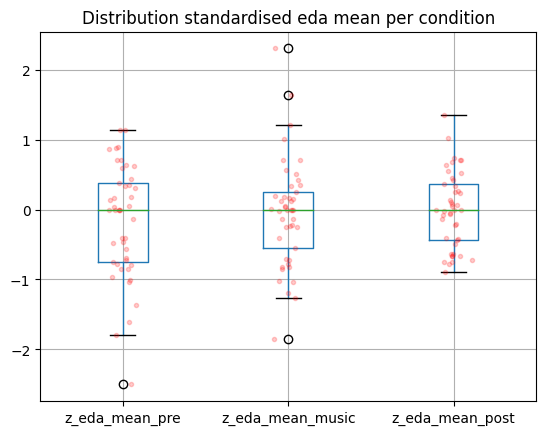

In [8]:
z_eda_conditions = ["z_eda_mean_pre", "z_eda_mean_music", "z_eda_mean_post"]

bp_mean_zeda = df_summary_eda_raw[z_eda_conditions].fillna(0).boxplot()

for n_condition, condition in enumerate(z_eda_conditions,1):

    y = df_summary_eda_raw[condition].fillna(0)
    # Add some random "jitter" to the x-axis
    x = np.random.normal(n_condition, 0.04, size=len(y))
    plt.plot(x, y, 'r.', alpha=0.2)
plt.title("Distribution standardised eda mean per condition")    
plt.show()

In [9]:
df_summary_eda_raw[["participant_id","session_id","majority_context"] + z_eda_conditions] 

,participant_id,session_id,majority_context,z_eda_mean_pre,z_eda_mean_music,z_eda_mean_post
0,P01,1,Goal-Attainment,-5.572607e-01,0.709544,-4.886026e-01
1,P01,2,Other,-4.041285e-01,-0.406939,1.349729e+00
2,P01,3,Goal-Attainment,1.146768e+00,-0.131113,-7.252775e-01
3,P01,4,Goal-Attainment,1.134439e+00,0.418512,-8.947673e-01
4,P01,5,Affective,8.967104e-01,0.253031,-7.512670e-01
5,P01,6,Eudaimonic,4.323257e-01,0.716772,-4.002011e-01
6,P01,7,Goal-Attainment,-7.801162e-01,-0.236847,7.376092e-01
7,P01,8,Other,-8.572273e-01,-1.273141,6.401746e-01
8,P01,9,Other,-6.901506e-01,-0.777631,6.756308e-01
9,P01,10,Other,-1.041255e+00,-1.042910,7.104180e-01


## Issue to Fix - Overlapped Sessions

In [10]:
df_summary_eda_raw[df_summary_eda_raw["overlap_group"]!=0].iloc[:,list(range(8)) + [-1]]

,participant_id,session_id,n_tracks,majority_context,time_start_pre,time_start_music,time_end_music,time_end_post,overlap_group
6,P01,7,22,Goal-Attainment,2025-01-07 09:48:53.521074,2025-01-07 10:40:16.667,2025-01-07 11:37:05.433000,2025-01-07 12:49:41.150315,1
7,P01,8,3,Other,2025-01-07 11:19:13.400315,2025-01-07 11:58:36.963,2025-01-07 12:08:08.553000,2025-01-07 13:19:50.150224,1
8,P01,9,6,Other,2025-01-07 12:19:28.400315,2025-01-07 13:17:53.165,2025-01-07 13:33:08.408000,2025-01-07 14:50:22.150407,1
9,P01,10,4,Other,2025-01-07 12:49:41.400224,2025-01-07 13:33:43.144,2025-01-07 13:50:47.018000,2025-01-07 15:20:22.150376,1
10,P01,11,1,Other,2025-01-07 13:19:50.400224,2025-01-07 13:50:47.555,2025-01-07 13:54:04.879253,2025-01-07 15:20:22.150376,1
11,P01,12,17,Affective,2025-01-07 21:21:33.367845,2025-01-07 21:52:26.641,2025-01-07 22:33:45.442000,2025-01-07 23:38:37.600246,2
12,P01,13,21,Affective,2025-01-07 21:51:39.348372,2025-01-07 22:35:48.198,2025-01-07 23:31:18.984000,2025-01-08 00:08:47.600200,2
14,P01,15,2,Other,2025-01-08 18:40:58.773184,2025-01-08 19:18:18.738,2025-01-08 19:21:35.187625,2025-01-08 20:41:19.522999,3
15,P01,16,9,Other,2025-01-08 18:40:58.773184,2025-01-08 19:21:20.802,2025-01-08 19:56:44.534000,2025-01-08 21:11:26.523170,3
17,P02,6,214,Other,2025-01-08 08:28:11.657990,2025-01-08 00:36:49.291,2025-01-08 08:48:44.896000,2025-01-08 09:57:00.047666,1


In [12]:
def _group_overlapped_dirs(path_duplicate_sessions):
    """
    Find groups of overlapped sessions in dataset.
    ---------
    Inputs:
        path_duplicate_sessions(str): Dataset root directory

    Outputs:
        overlapped_sessions(dict): Map between participant root directory and group of overlapped sessions
    """

    # Get all sessions' paths of participants in dataset
    participant_sessions = {os.path.join(path_duplicate_sessions, dir): sorted(os.listdir(os.path.join(path_duplicate_sessions, dir)))
                        for dir in os.listdir(path_duplicate_sessions) if re.search(r"P\d+", dir)}
    overlapped_sessions = dict((key, []) for key in participant_sessions.keys())

    # Iterate sessions and find conflict with timestamps
    for dir_p, sessions in participant_sessions.items():
        
        # Get first participant session
        c_session = sessions[0]
        c_end = c_session.split("_")[1]
        c_group = [c_session]

        # Check if subsequent sessions overlapped with current sessions
        for n_session in sessions[1:]:
            n_start,n_end,_ = n_session.split("_")

            # Check overlap
            if n_start <= c_end:  
                c_group.append(n_session)
                c_end = max(c_end, n_end)  # Extend the end time
            else: 
                overlapped_sessions[dir_p].append(c_group)  # Save the current group
                c_group = [n_session]  # Start a new group
                c_end = n_end
        
        # Add the last group
        overlapped_sessions[dir_p].append(c_group)  

    return overlapped_sessions

def _merge_overlapped_sessions(overlapped_dirs, path_new_dataset):
    """
    Combine groups of overlapped sessions and save in new path
    --------
    Inputs:
        overlapped_dirs(dict): Mapt paticipants' root path and group of overlapped sessions
        path_new_dataset(str): Path new dataset

    Outputs:
        None
    
    """
    # Iterate group of overlapped sessions of participants
    for p_dir, o_groups in overlapped_dirs.items():
        for o_dirs in o_groups:
            
            # Create new directory for overlapped session
            ts_start = o_dirs[0].split("_")[0]
            ts_end = o_dirs[-1].split("_")[1]
            ts_session_end = o_dirs[-1].split("_")[-1]
            combined_group = f"{ts_start}_{ts_end}_{ts_session_end}"
            new_path = os.path.join(path_new_dataset, os.path.split(p_dir)[-1],combined_group)
            os.makedirs(new_path, exist_ok=True)

            # Get all physio files and remove tracks file
            o_paths = [os.path.join(p_dir, dir) for dir in o_dirs]
            physio_files = [file for file in os.listdir(o_paths[0]) if file !="tracks.csv"]

            # Iterate physiological data in overlapped session
            for physio in physio_files:
                try:
                    # Concat all, remove duplicates, reorder and reset index
                    df_physio = (pd.concat([pd.read_csv(os.path.join(path_dup, physio)) for path_dup in o_paths])
                                .drop_duplicates()
                                .pipe(lambda df: df.sort_values(by=df.columns[0]))  # Sort by the first column (timestamp)
                                .reset_index(drop=True))
                    df_physio.to_csv(os.path.join(new_path, physio), index=False)
                except Exception as e:
                    print(f"An error occur when processing overlap group {combined_group}: {e}")

                # Combine tracks of overlapped sessions in single file
                df_tracks = (pd.concat([pd.read_csv(os.path.join(path_dup, "tracks.csv")) for path_dup in o_paths]).reset_index(drop=True))
                df_tracks.to_csv(os.path.join(new_path, "tracks.csv"), index=False)

    return


def remove_duplicate_physio(path_duplicate_sessions, path_clean):
    """
    
    """

    # Find and group overlapped sessions for each participant
    overlapped_sessions_dirs = _group_overlapped_dirs(path_duplicate_sessions)

    # Fuse overlapped sessions and save in new directory
    _merge_overlapped_sessions(overlapped_sessions_dirs, path_clean)

    return


# remove_duplicate_physio(RAW_DATA_PATH, "../data/clean")

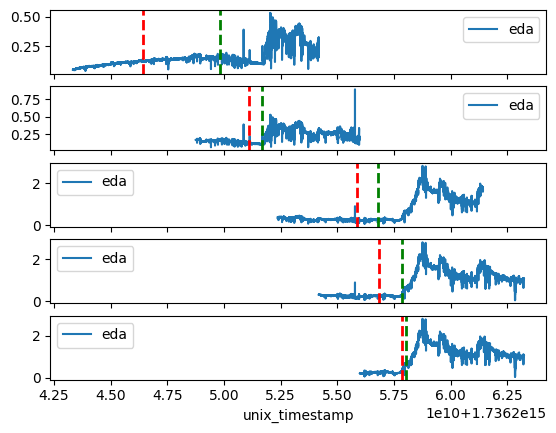

In [13]:
fig, axes = plt.subplots(nrows=5,
                         ncols=1,
                         sharex=True)

path_duplicate_sessions_1 = ["../data/raw/P01/1736243333_1736252368_07",
                           "../data/raw/P01/1736248753_1736254181_08",
                           "../data/raw/P01/1736252368_1736259617_09",
                           "../data/raw/P01/1736254181_1736261422_10",
                           "../data/raw/P01/1736255990_1736261422_11",
]

for n_ax, path_dup in enumerate(path_duplicate_sessions_1):
    pd.read_csv(os.path.join(path_dup, "eda.csv")).plot(x="unix_timestamp", y="eda", ax=axes[n_ax])
    axes[n_ax].axvline(pd.read_csv(os.path.join(path_dup, "tracks.csv"))["started_at"].iloc[0], color='r', linestyle='--', lw=2)
    axes[n_ax].axvline(pd.read_csv(os.path.join(path_dup, "tracks.csv"))["ended_at"].iloc[-1], color='g', linestyle='--', lw=2)


plt.show()


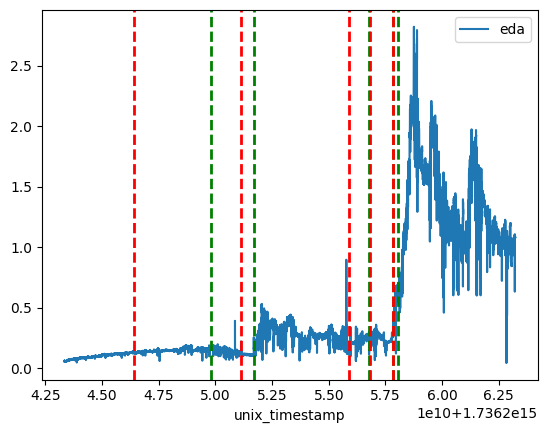

In [14]:
pd.read_csv("../data/clean/P01/1736243333_1736261422_11/eda.csv").plot(x="unix_timestamp", y="eda")

start_overlapped_sessions_1 = (pd.read_csv("../data/clean/P01/1736243333_1736261422_11/tracks.csv")
                                .groupby("listening_session_id")
                                .apply(lambda x: x.iloc[[0]]
                                        .reset_index(drop=True))["started_at"])

end_overlapped_sessions_1 = (pd.read_csv("../data/clean/P01/1736243333_1736261422_11/tracks.csv")
 .groupby("listening_session_id")
 .apply(lambda x: x.iloc[[-1]]
        .reset_index(drop=True))["ended_at"].values)

for start_ovl_1,end_ovl_1 in zip(start_overlapped_sessions_1, end_overlapped_sessions_1):
    plt.axvline(start_ovl_1, color='r', linestyle='--', lw=2)
    plt.axvline(end_ovl_1, color='g', linestyle='--', lw=2)

plt.show()

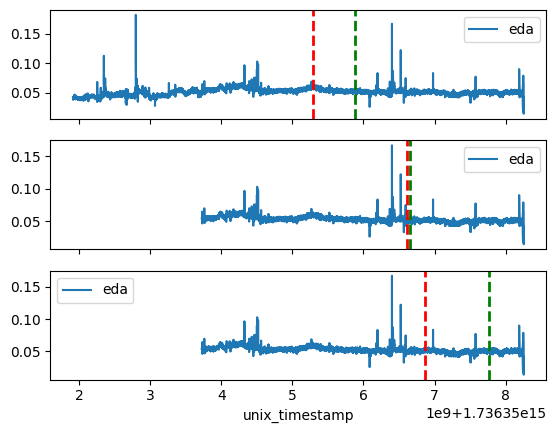

In [15]:
fig, axes = plt.subplots(nrows=3,
                         ncols=1,
                         sharex=True)

path_duplicate_sessions_2 = ["../data/raw/P02/1736351916_1736358218_15",
                           "../data/raw/P02/1736353728_1736358218_16",
                           "../data/raw/P02/1736353728_1736358218_17",
]

for n_ax, path_dup in enumerate(path_duplicate_sessions_2):
    pd.read_csv(os.path.join(path_dup, "eda.csv")).plot(x="unix_timestamp", y="eda", ax=axes[n_ax])
    axes[n_ax].axvline(pd.read_csv(os.path.join(path_dup, "tracks.csv"))["started_at"].iloc[0], color='r', linestyle='--', lw=2)
    axes[n_ax].axvline(pd.read_csv(os.path.join(path_dup, "tracks.csv"))["ended_at"].iloc[-1], color='g', linestyle='--', lw=2)

plt.show()

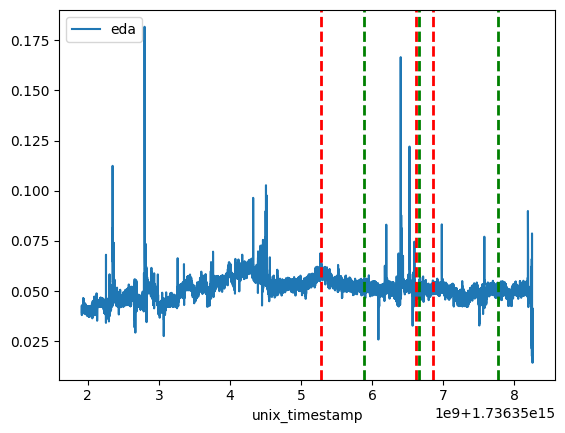

In [16]:
pd.read_csv("../data/clean/P02/1736351916_1736358218_17/eda.csv").plot(x="unix_timestamp", y="eda")

start_overlapped_sessions_2 = (pd.read_csv("../data/clean/P02/1736351916_1736358218_17/tracks.csv")
                                .groupby("listening_session_id")
                                .apply(lambda x: x.iloc[[0]]
                                        .reset_index(drop=True))["started_at"])

end_overlapped_sessions_2 = (pd.read_csv("../data/clean/P02/1736351916_1736358218_17/tracks.csv")
 .groupby("listening_session_id")
 .apply(lambda x: x.iloc[[-1]]
        .reset_index(drop=True))["ended_at"].values)

for start_ovl_2,end_ovl_2 in zip(start_overlapped_sessions_2, end_overlapped_sessions_2):
    plt.axvline(start_ovl_2, color='r', linestyle='--', lw=2)
    plt.axvline(end_ovl_2, color='g', linestyle='--', lw=2)


In [17]:
df_summary_eda_clean = get_summary_sessions("../data/clean")
df_summary_eda_clean[["participant_id","session_id","majority_context"] + minutes_condition]

,participant_id,session_id,majority_context,time_minutes_pre,time_minutes_music,time_minutes_post
0,P01,1,Goal-Attainment,42.162500,76.091667,62.412500
1,P01,2,Other,52.366667,225.858333,83.775000
2,P01,3,Goal-Attainment,53.937500,13.850000,82.779167
3,P01,4,Goal-Attainment,51.454167,43.554167,85.608333
4,P01,5,Affective,40.154167,46.766667,63.679167
5,P01,6,Eudaimonic,43.600000,21.533333,85.666667
6,P01,11,Goal-Attainment,51.391667,193.800000,86.291667
7,P01,13,Affective,30.891667,98.662500,37.479167
8,P01,14,Goal-Attainment,26.037500,139.633333,75.679167
9,P01,16,Other,37.333333,38.433333,74.700000


# All Physiology

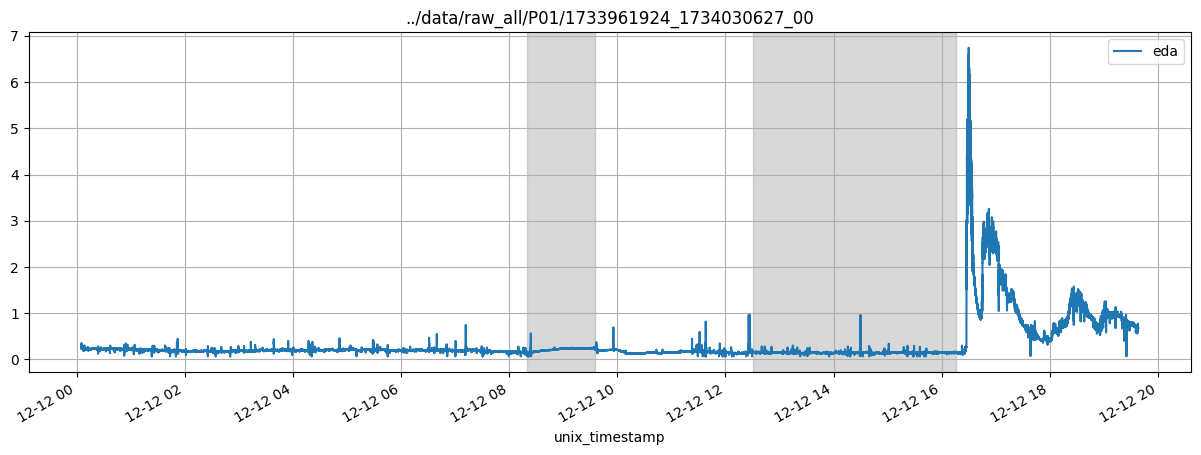

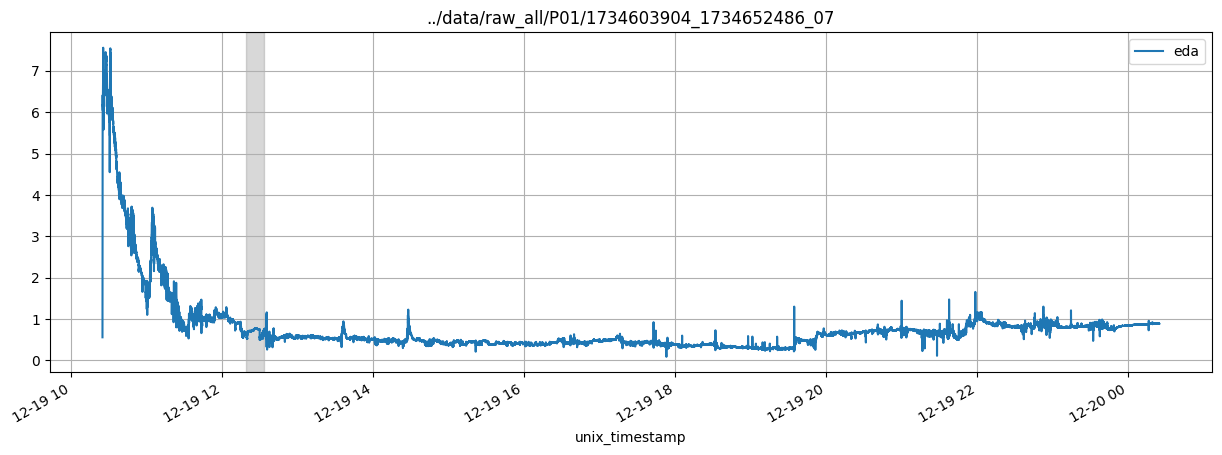

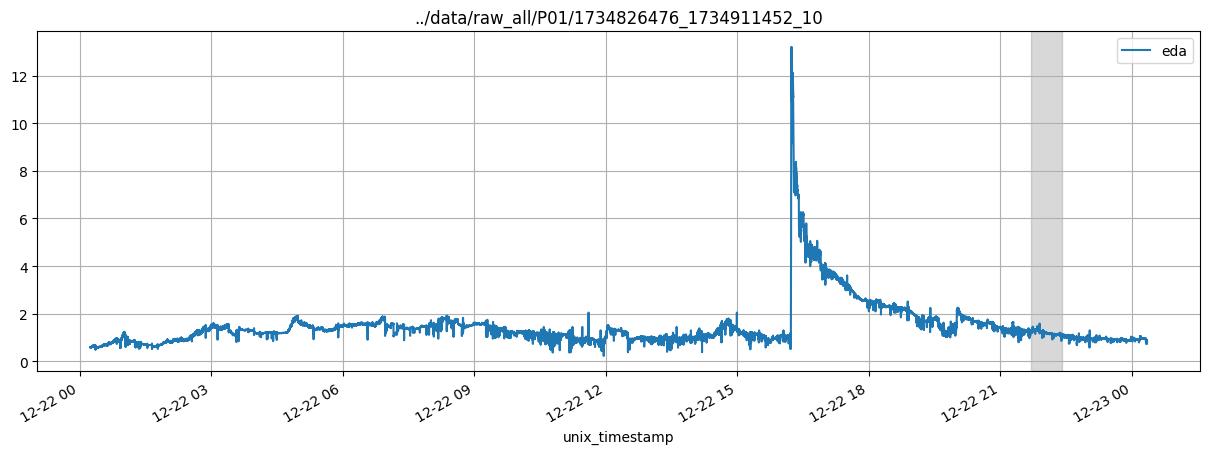

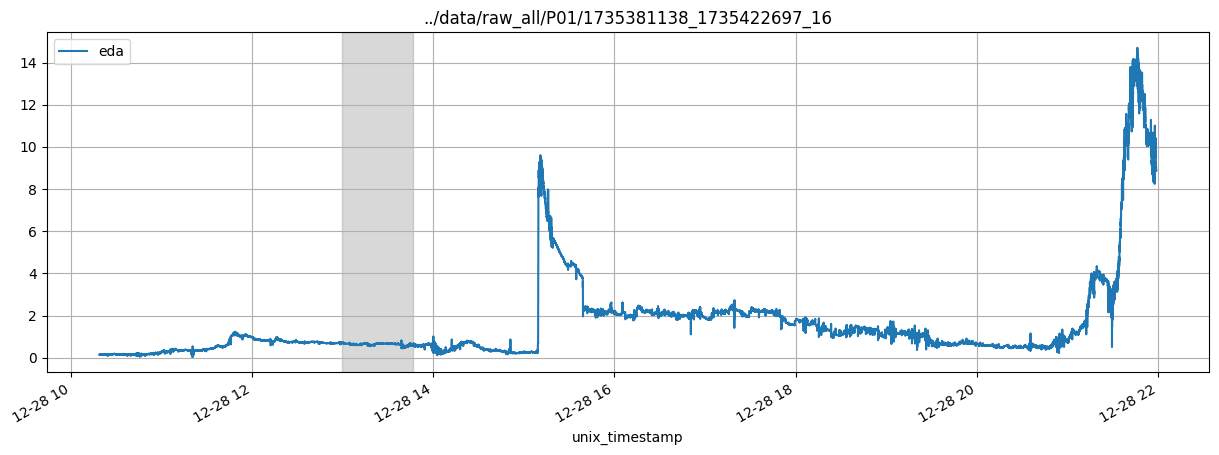

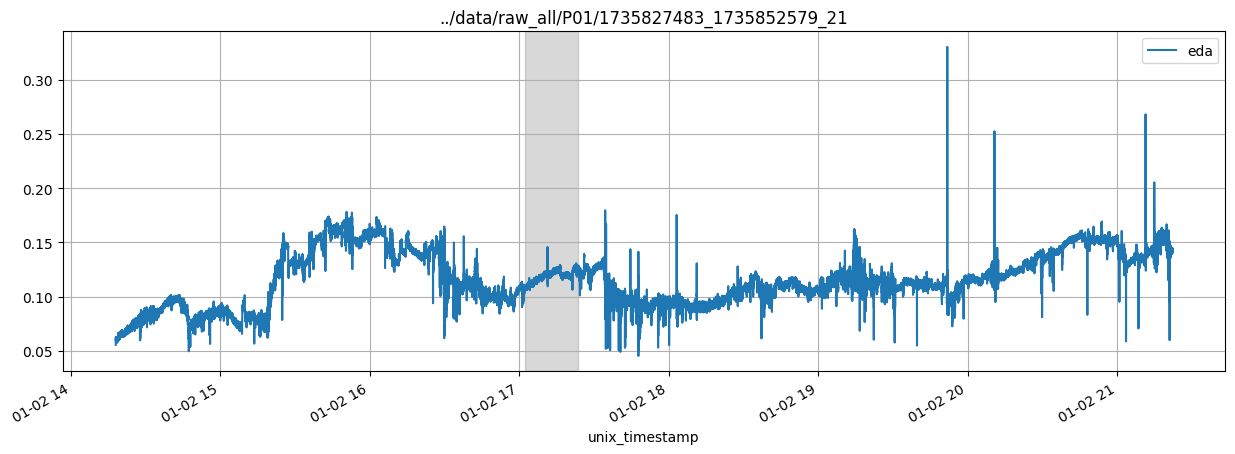

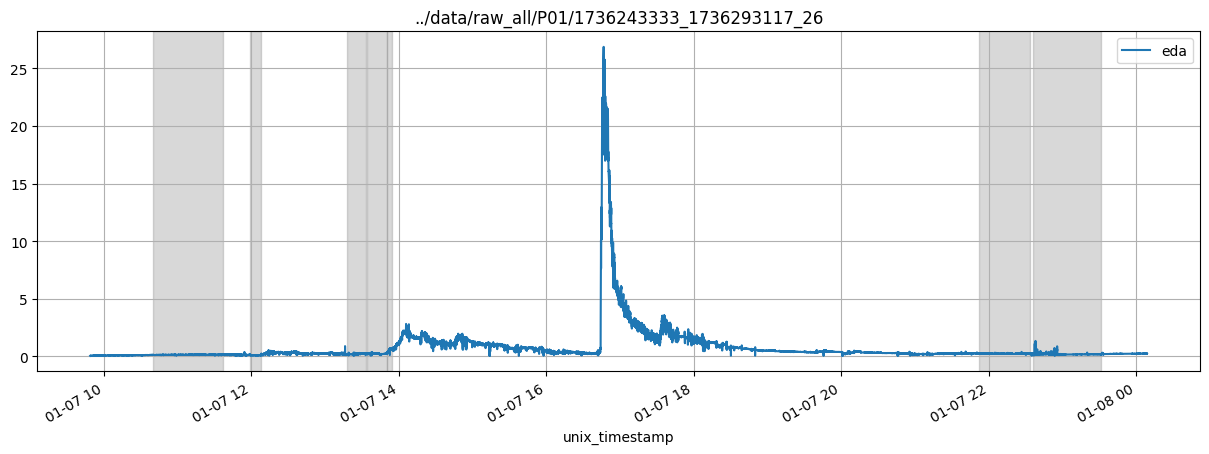

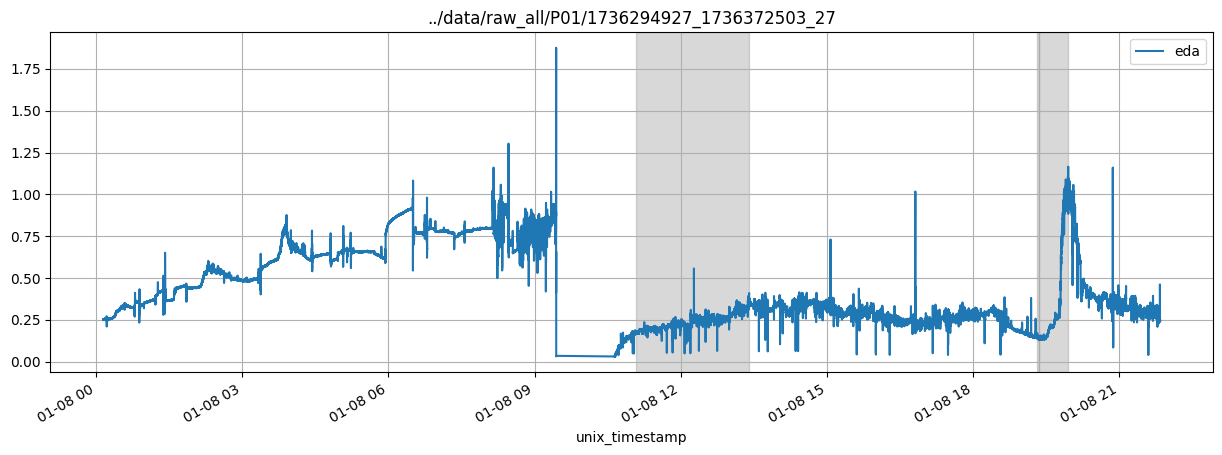

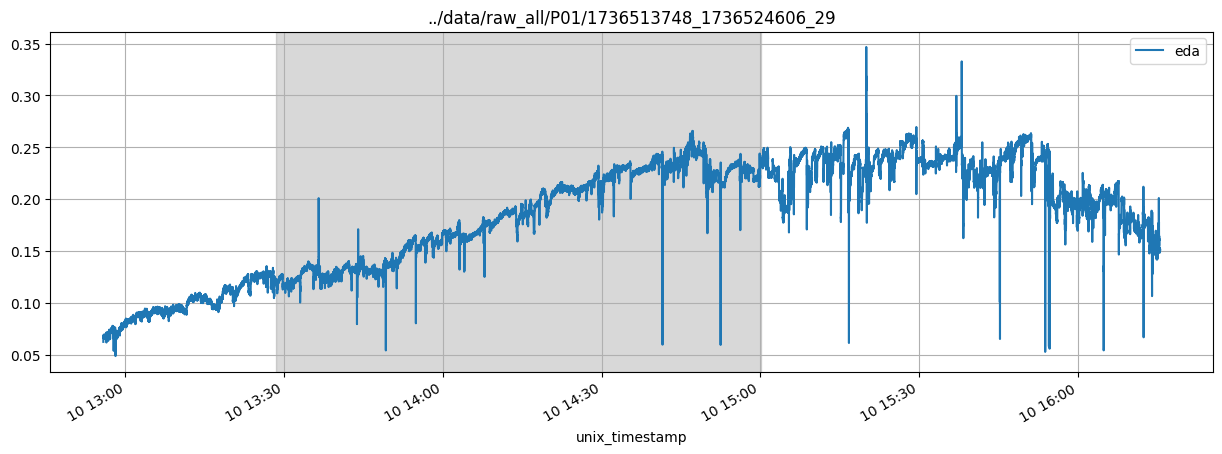

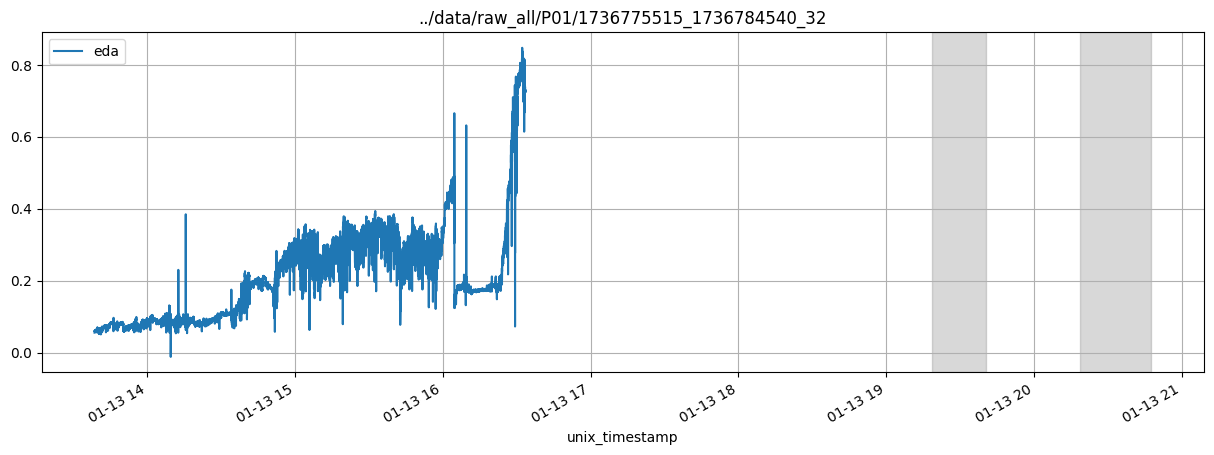

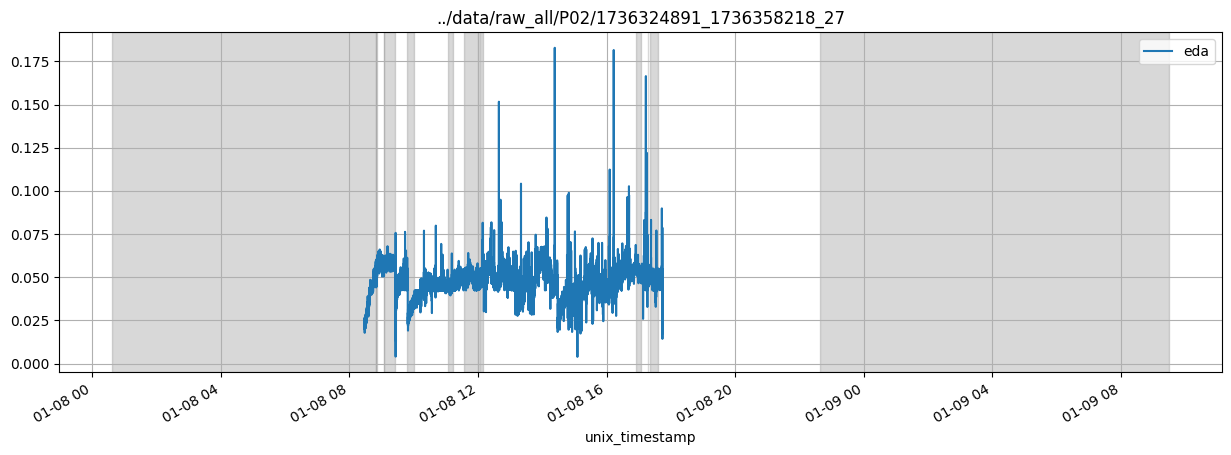

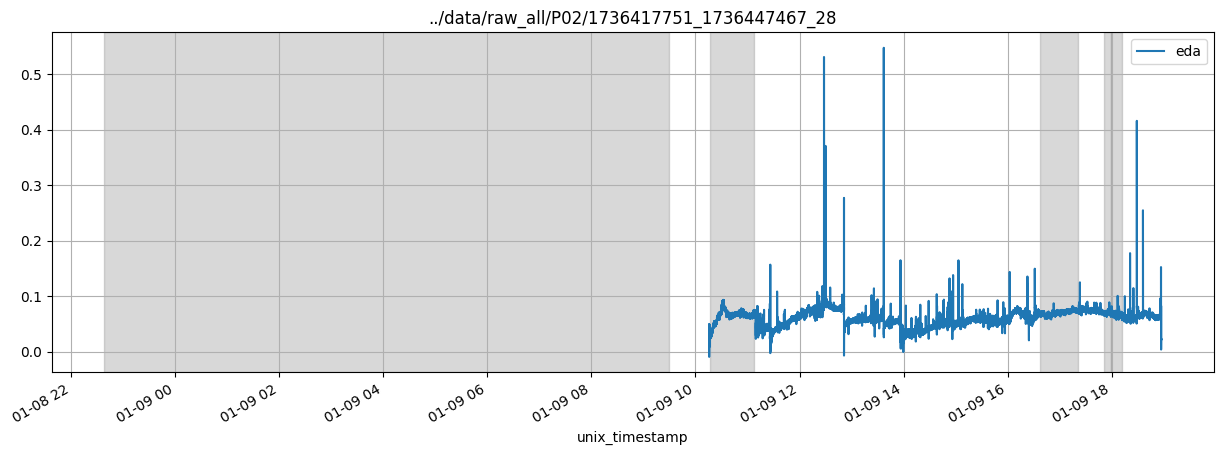

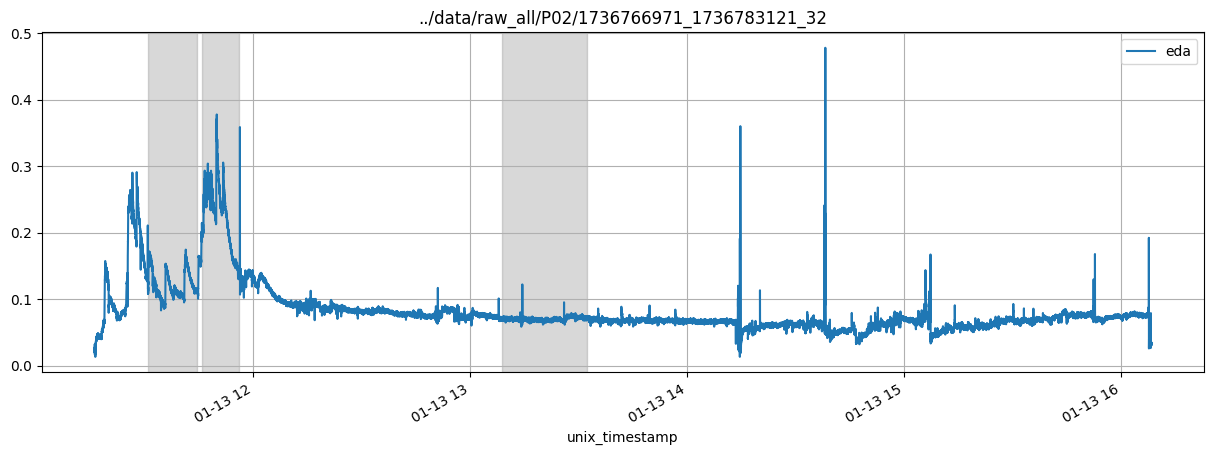

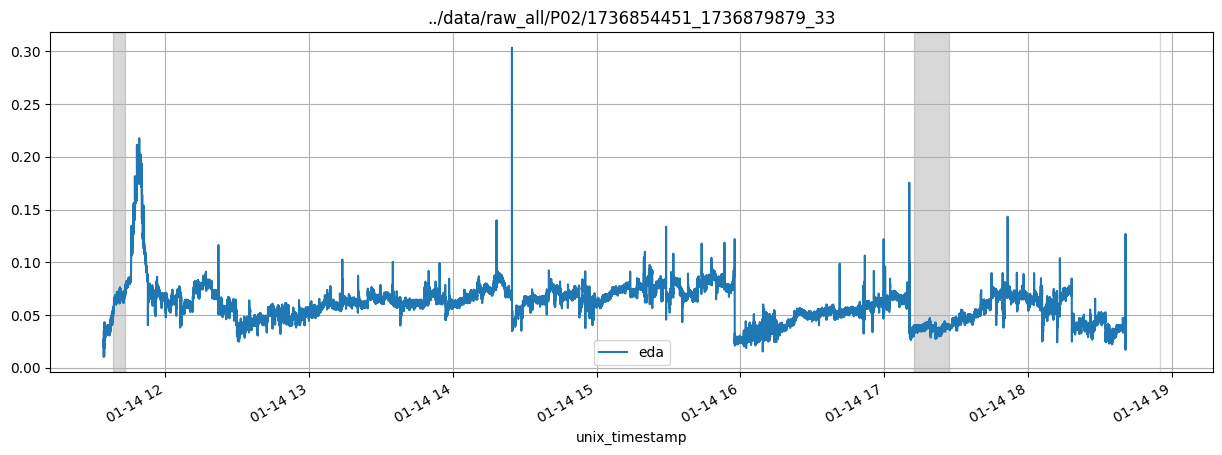

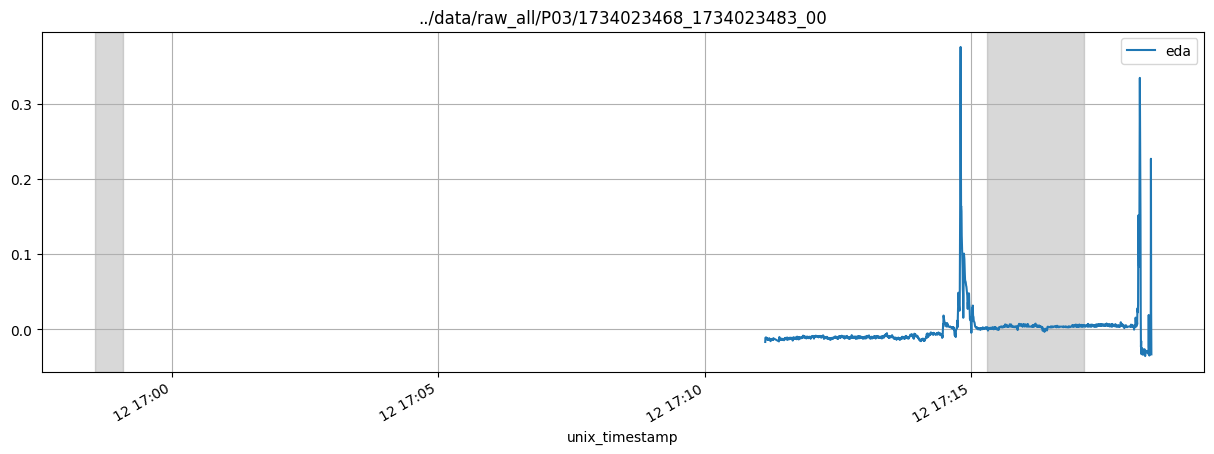

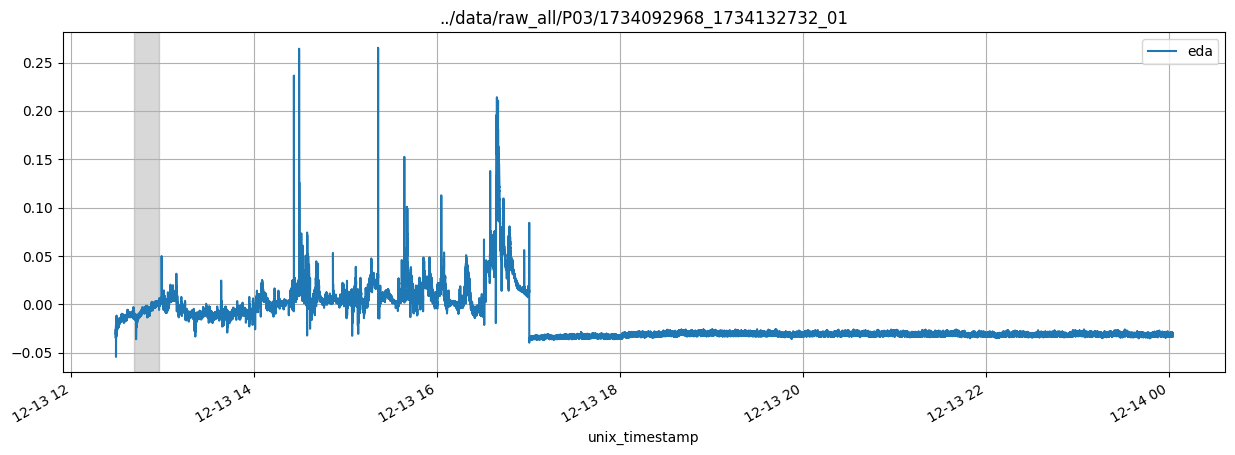

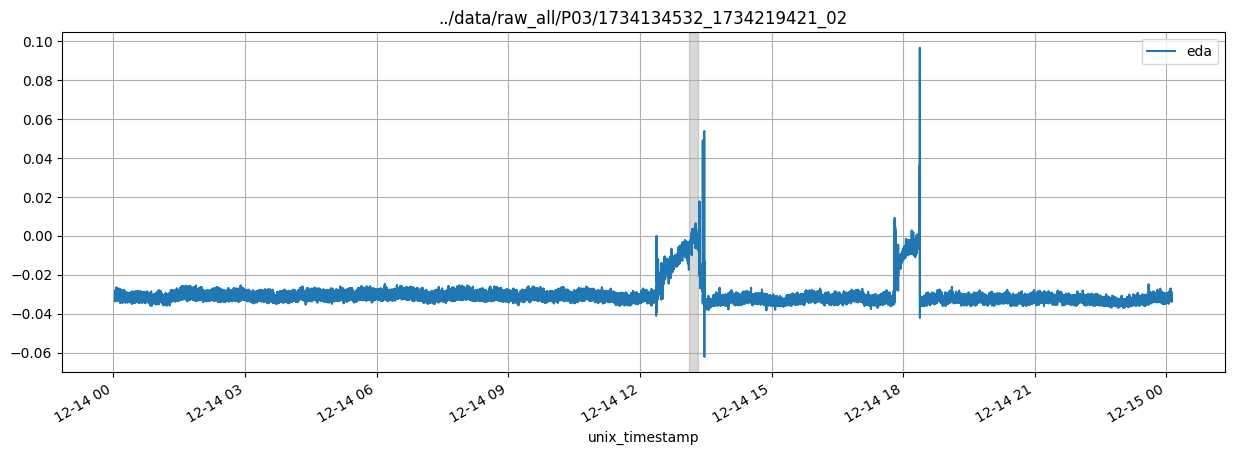

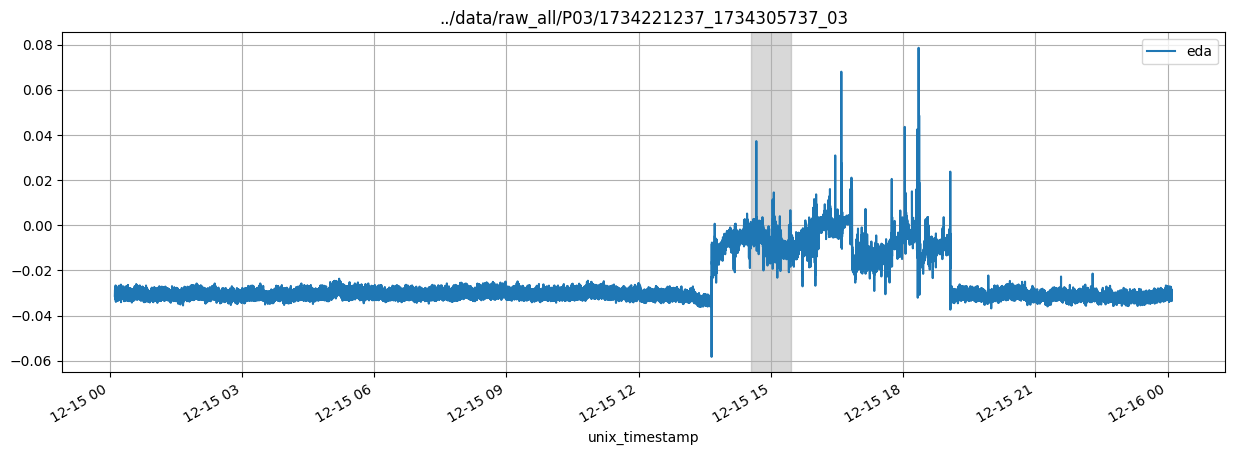

In [18]:
participant_sessions = {os.path.join("../data/raw_all", dir): sorted(os.listdir(os.path.join('../data/raw_all', dir)))
                        for dir in sorted(os.listdir("../data/raw_all")) if re.search(r"P\d+", dir)}

for p_dir, p_sessions in participant_sessions.items():
    for daily_session in p_sessions:
        fig, ax = plt.subplots(figsize=(15,5))
        
        df_eda_daily = pd.read_csv(os.path.join(p_dir, daily_session, "eda.csv"))
        df_eda_daily["unix_timestamp"] = pd.to_datetime(df_eda_daily["unix_timestamp"], unit="us")

        df_tracks_daily = pd.read_csv(os.path.join(p_dir, daily_session, "tracks.csv"))
        df_tracks_daily["started_at"] = pd.to_datetime(df_tracks_daily["started_at"], unit="us")
        df_tracks_daily["ended_at"] = pd.to_datetime(df_tracks_daily["ended_at"], unit="us")

        starts_music_daily = df_tracks_daily.groupby("listening_session_id")["started_at"].first().reset_index(drop=True)
        ends_music_daily = df_tracks_daily.groupby("listening_session_id")["ended_at"].last().reset_index(drop=True)
        
        df_eda_daily.plot(x="unix_timestamp", y="eda", ax=ax)
        for start_music, end_music in zip(starts_music_daily, ends_music_daily):
            ax.axvspan(start_music, end_music, color="gray", alpha=0.3)

        plt.title(os.path.join(p_dir, daily_session))
        plt.grid()
        plt.show()
        

# Compare Spotify Time History

In [ ]:
my_history = "../data/raw/P01"
last_session = os.path.join(my_history, sorted(os.listdir(my_history))[-1], "tracks.csv")

df_last_session = pd.read_csv(last_session)
df_last_session["started_at"] = pd.to_datetime(df_last_session['started_at'],unit='us')
df_last_session["ended_at"] = pd.to_datetime(df_last_session['ended_at'],unit='us')

df_last_session

In [ ]:
# Define scope to get access to relevant information.
scope = "user-read-recently-played playlist-read-private playlist-modify-private"

# Authorization is required to access user information. 
# The redirect_uri parameter must match the one specified in the application
# Enter access token found in browser to input in text editor. Consider creating a backend service for this.
auth = SpotifyOAuth(client_id=os.environ.get("SPOTIPY_CLIENT_ID"), client_secret=os.environ.get("SPOTIPY_CLIENT_SECRET"),
                    scope=scope, redirect_uri="https://localhost:8888/callback")
sp_auth = spotipy.Spotify(auth_manager=auth)


def get_most_recent_spotify(sp_client, n_last_songs):
    """
    Get the 50 most recent songs listened by the user.
    Spotify does not make the whole listening history available through its API
    --------------

    Inputs:
        after(int): UTC time to start retreiving most recent listened songs.
        sp_client(spotipy): Spotipy client object
    Outputs:
        df_spotify_history(pd.DataFrame): Dataframe with records of 50 most recent listened songs
    
    """

    tracks_history = []

    recently_played = sp_client.current_user_recently_played(limit=n_last_songs)

    # Get relevant attributes
    for track_played in recently_played["items"]:
        listened_track = {"name": track_played["track"]["name"],
                        "ended_at":track_played["played_at"],
                        "duration_ms": track_played["track"]["duration_ms"]}
        tracks_history.append(listened_track)

    # Create dataframe and process data
    df_spotify_history = pd.DataFrame(tracks_history)
    df_spotify_history["ended_at"] = (pd.to_datetime(df_spotify_history["ended_at"])).dt.tz_localize(None)
    df_spotify_history["started_at"] = df_spotify_history["ended_at"] - pd.to_timedelta(df_spotify_history['duration_ms'], unit='ms')
    df_spotify_history["sequence"] = ((df_spotify_history["started_at"].shift(1) - df_spotify_history["ended_at"]) < timedelta(seconds=1)).shift(-1)
    df_spotify_history["player_interaction"] = (((pd.Timedelta(seconds=1) < (df_spotify_history["started_at"].shift(1) - df_spotify_history["ended_at"])) & 
                            (df_spotify_history["started_at"].shift(1) - df_spotify_history["ended_at"] < pd.Timedelta(minutes=1)))
                            .shift(-1).fillna(False))
    df_spotify_history["start_session"] = (df_spotify_history['sequence'] == False) & (df_spotify_history['sequence'].shift(1) == True)
    df_spotify_history["start_conflict"] = ((df_spotify_history["started_at"].shift(1) - df_spotify_history["ended_at"]) < pd.Timedelta(0)).shift(-1).fillna(False)
    df_spotify_history["sequence"] = (df_spotify_history["sequence"] | df_spotify_history["start_session"]) & (~df_spotify_history["start_conflict"])
    df_spotify_history["end_session"] = (df_spotify_history['sequence'] == True) & (df_spotify_history['sequence'].shift(1) == False)

    df_spotify_history = (df_spotify_history[["name", "started_at", "ended_at", "duration_ms"] + list(df_spotify_history.columns[4:])]
                          .sort_values(by="started_at")
                          .reset_index(drop=True)
    )

    return df_spotify_history

df_spotify_history = get_most_recent_spotify(sp_auth, len(df_last_session))
df_spotify_history

In [ ]:
abs(df_last_session["started_at"] - df_spotify_history["started_at"].shift(-1))

In [ ]:
abs(df_last_session["ended_at"] - df_spotify_history["ended_at"].shift(-1))